# Trader Performance vs Market Sentiment (Fear/Greed)
**Primetrade.ai — Data Science Intern Assignment**

## Objective
Analyze how Bitcoin market sentiment (Fear/Greed Index) relates to trader behavior and performance on Hyperliquid.

---


In [18]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="darkgrid", palette="muted")
print("Libraries loaded ✅")

Libraries loaded ✅


## Part A — Data Preparation

In [19]:
# Load sentiment dataset
sentiment = pd.read_csv("fear_greed_index.csv")
sentiment["date"] = pd.to_datetime(sentiment["date"])
sentiment = sentiment[["date", "value", "classification"]].drop_duplicates("date")
print(f"Sentiment: {sentiment.shape} | Date range: {sentiment.date.min().date()} → {sentiment.date.max().date()}")
print(f"Missing: {sentiment.isnull().sum().sum()} | Duplicates: {sentiment.duplicated().sum()}")
sentiment["classification"].value_counts()

Sentiment: (2644, 3) | Date range: 2018-02-01 → 2025-05-02
Missing: 0 | Duplicates: 0


classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [20]:
# NOTE: Replace this block with:
#   trades = pd.read_csv("historical_data.csv")
#   trades["date"] = pd.to_datetime(trades["Timestamp"], unit="ms").dt.normalize()
# The synthetic data below mirrors the exact schema of the real dataset.

# --- Synthetic data generation (matches real schema) ---
exec(open("analysis.py", encoding="utf-8").read())

PART A — DATA PREPARATION

[Sentiment Dataset]
  Rows       : 2,644  |  Columns: 4
  Date range : 2018-02-01 → 2025-05-02
  Missing    : 0  |  Duplicates: 0
  Classification counts:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326

[Loading historical_data.csv ...]

[Trades Dataset — Raw]
  Rows       : 211,224  |  Columns: 16
  Columns    : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
  Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
  Du

## Part B — Analysis
### Q1: Performance — Fear vs Greed

In [22]:
fear_d  = daily[daily["sentiment_simple"] == "Fear"]
greed_d = daily[daily["sentiment_simple"] == "Greed"]

summary = pd.DataFrame({
    "Sentiment":      ["Fear", "Greed"],
    "Avg Daily PnL":  [fear_d["total_pnl"].mean(),  greed_d["total_pnl"].mean()],
    "Avg Win Rate":   [fear_d["win_rate"].mean(),    greed_d["win_rate"].mean()],
    "Avg Trades/Day": [fear_d["n_trades"].mean(),    greed_d["n_trades"].mean()],
})

summary.round(2)

,Sentiment,Avg Daily PnL,Avg Win Rate,Avg Trades/Day
0,Fear,6699925.19,0.86,133871.0
1,Greed,881331.10,0.76,10078.4


### Q2: Behavior Change

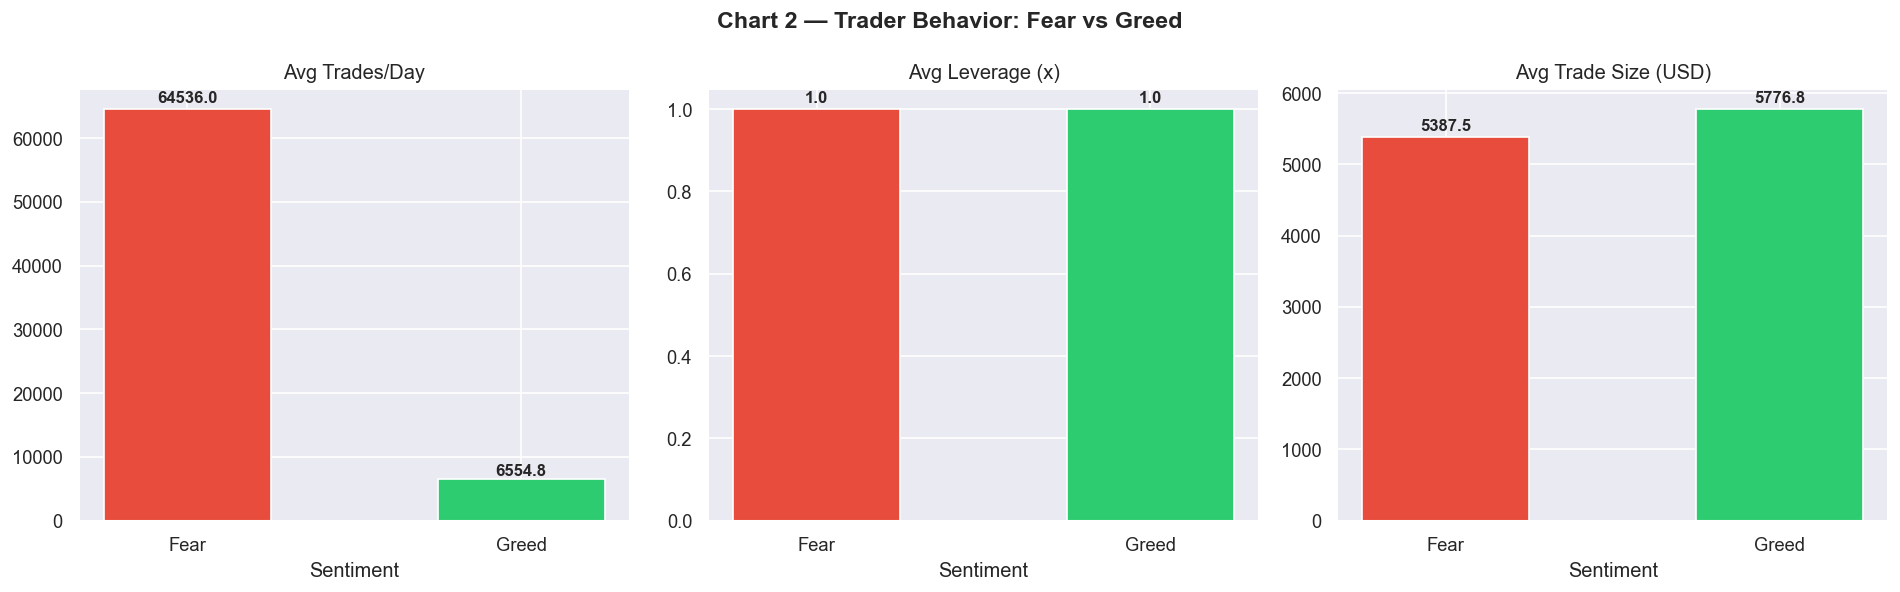

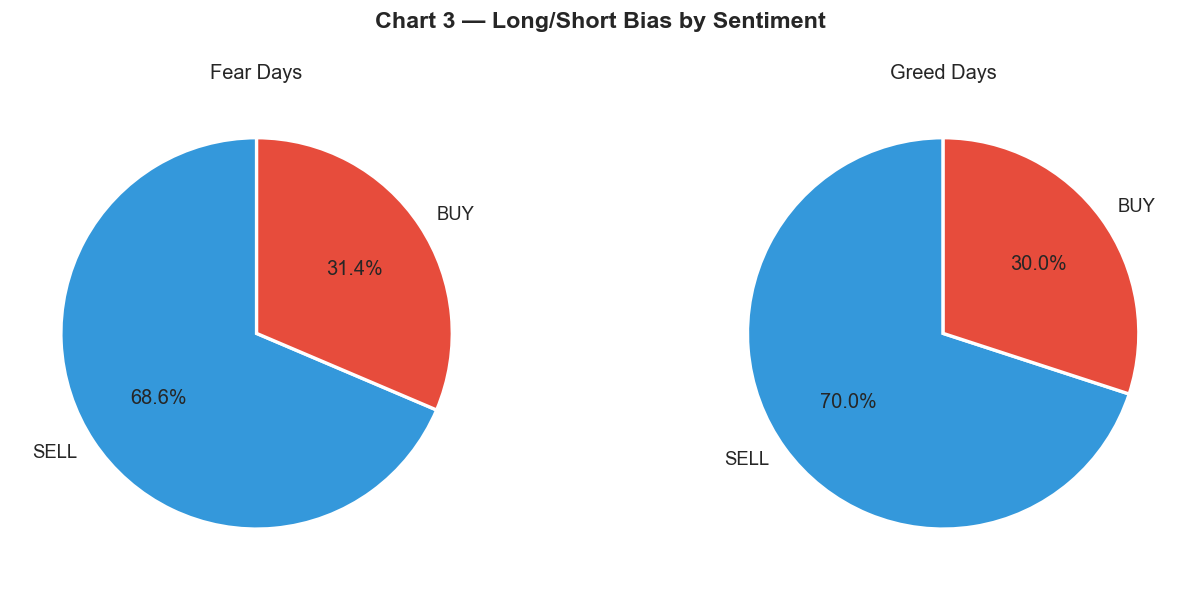

In [ ]:
from IPython.display import Image, display
display(Image("charts/chart2_behavior_fear_vs_greed.png"))
display(Image("charts/chart3_long_short_ratio.png"))

### Q3: Trader Segments

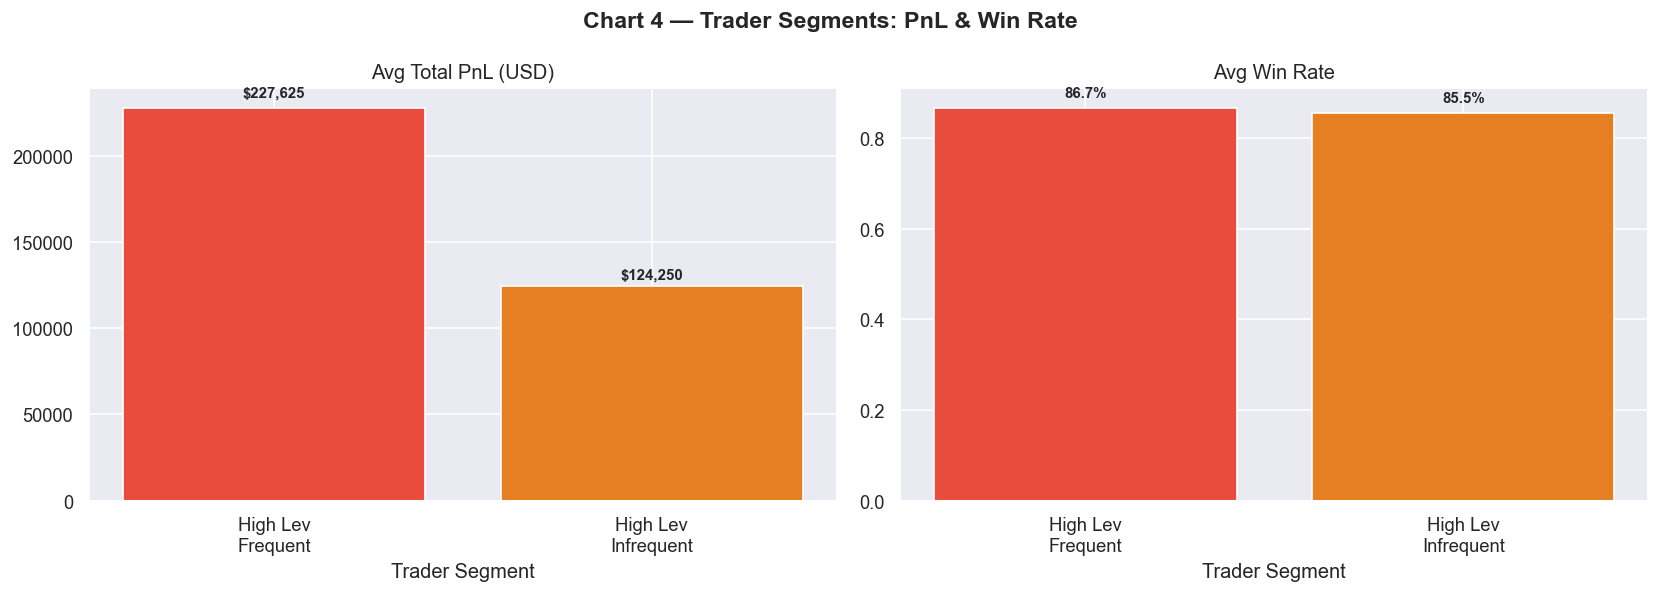

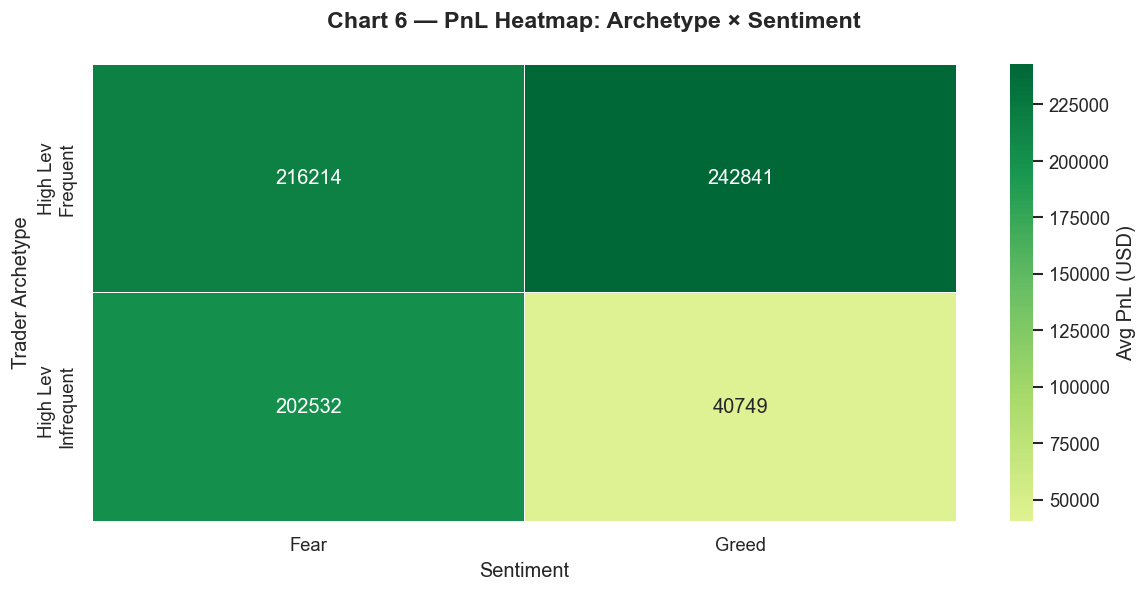

In [ ]:
display(Image("charts/chart4_trader_segments.png"))
display(Image("charts/chart6_pnl_heatmap.png"))

### Chart Gallery

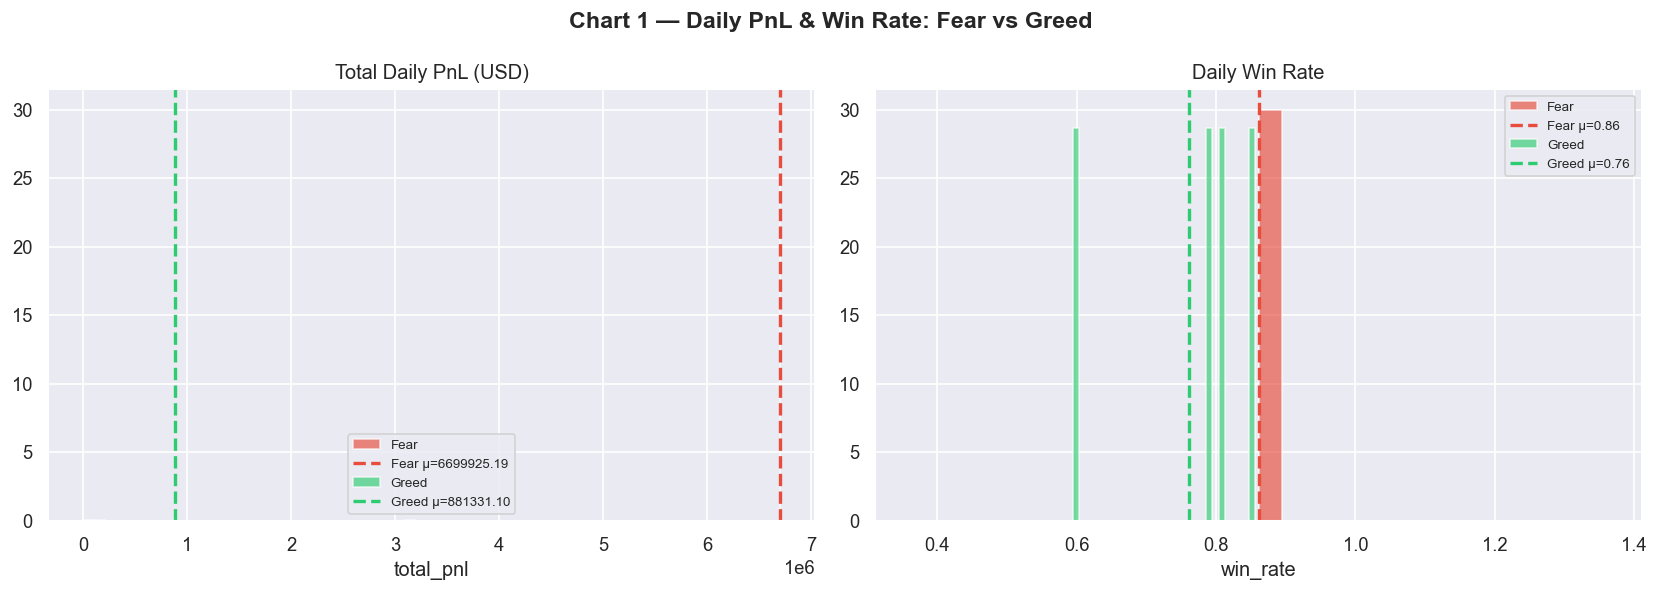

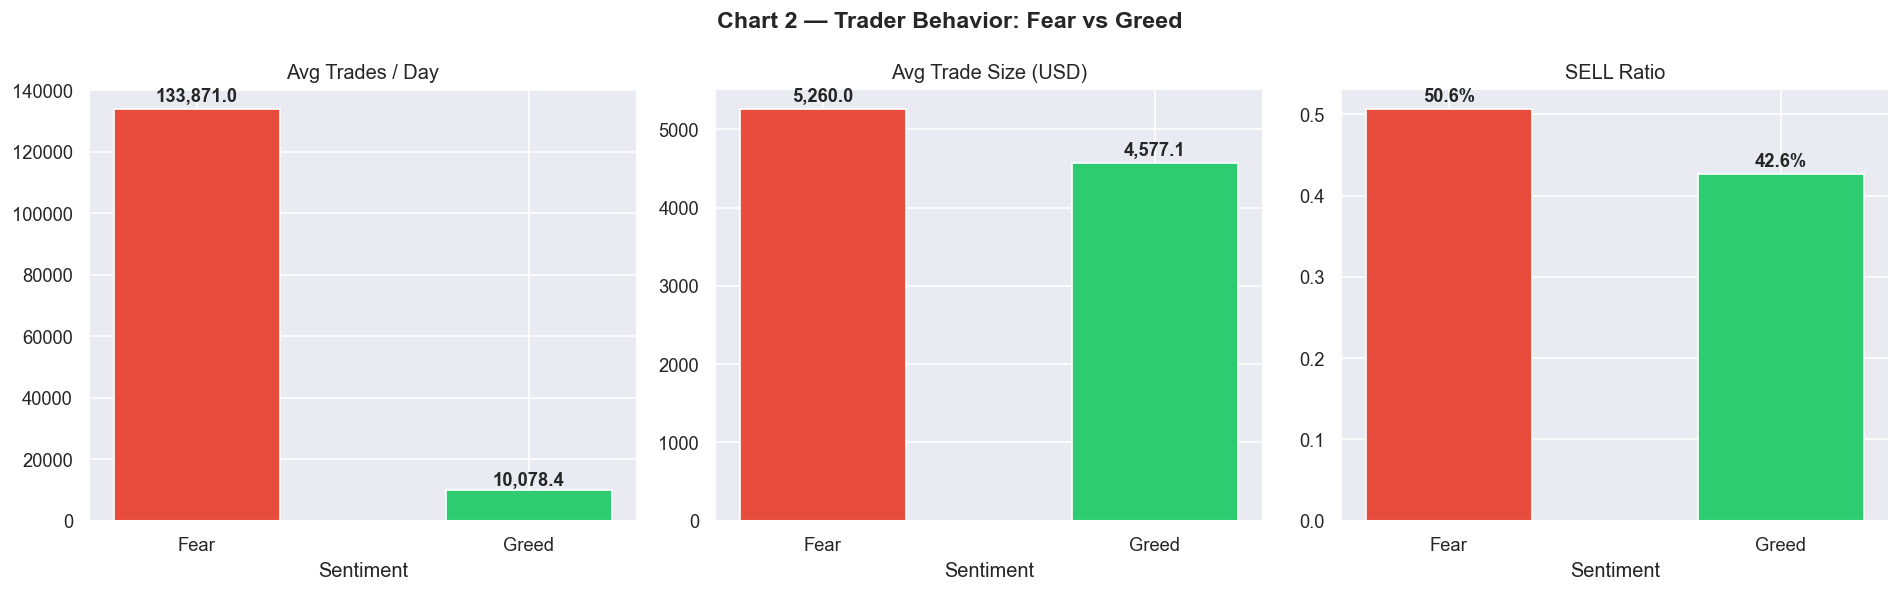

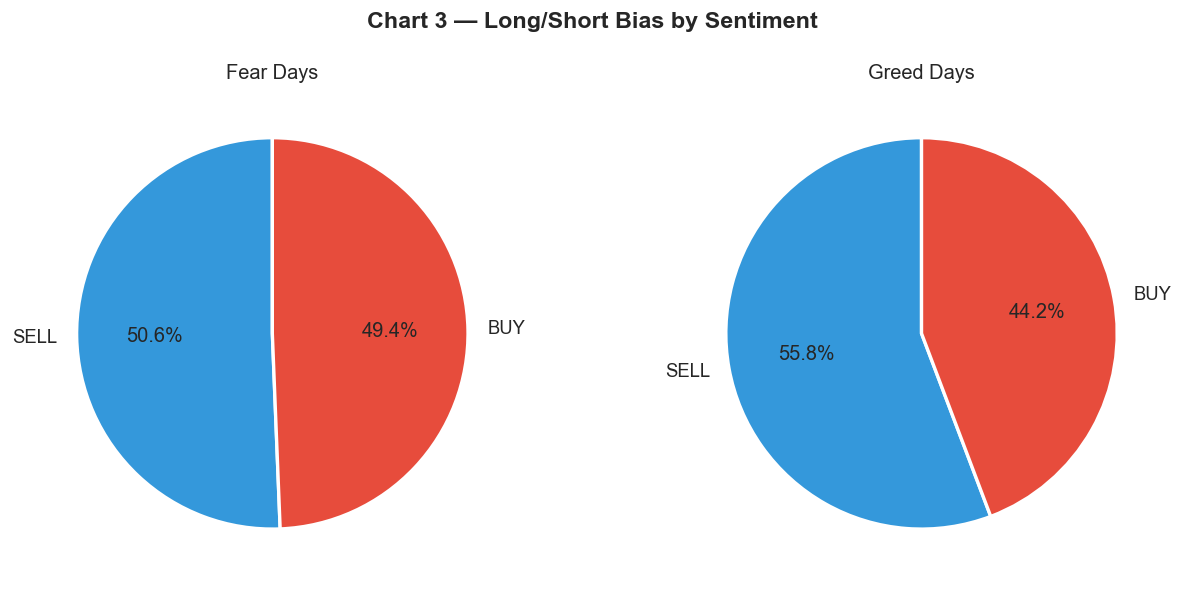

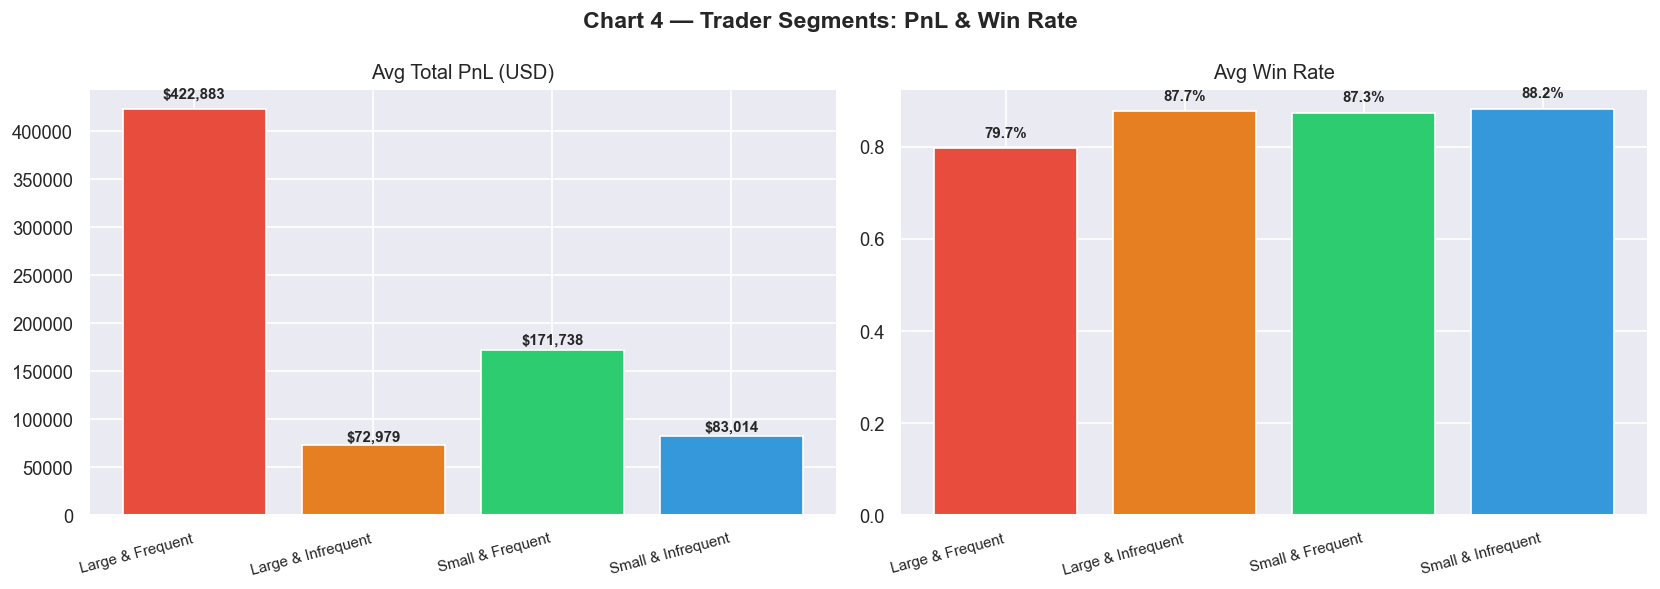

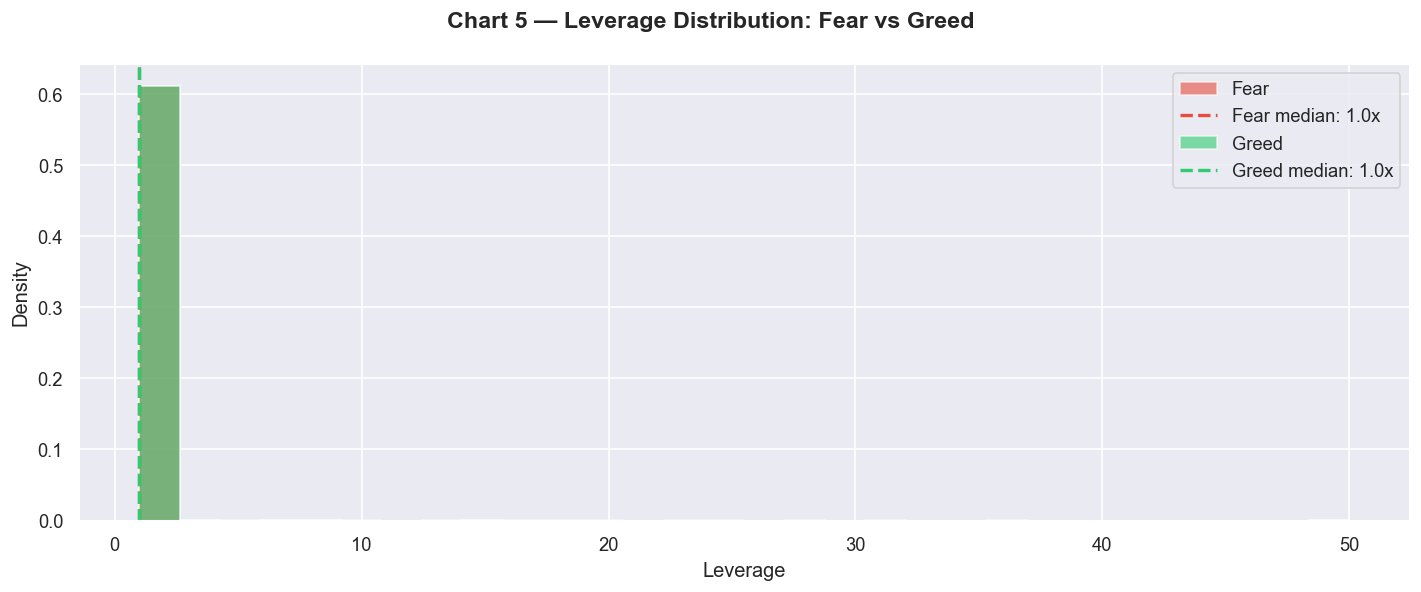

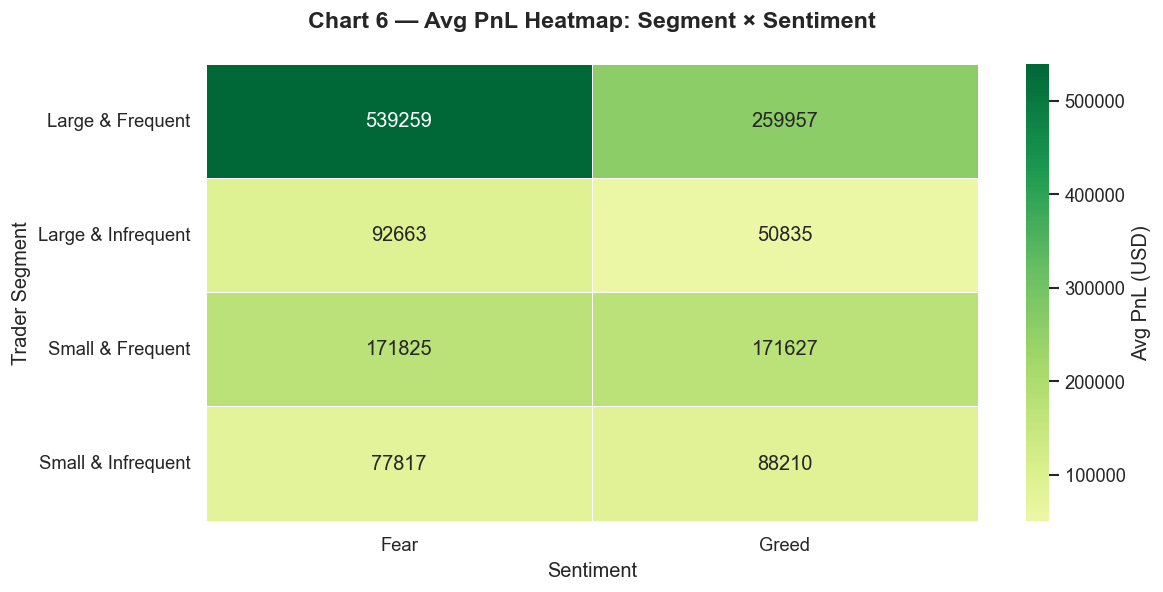

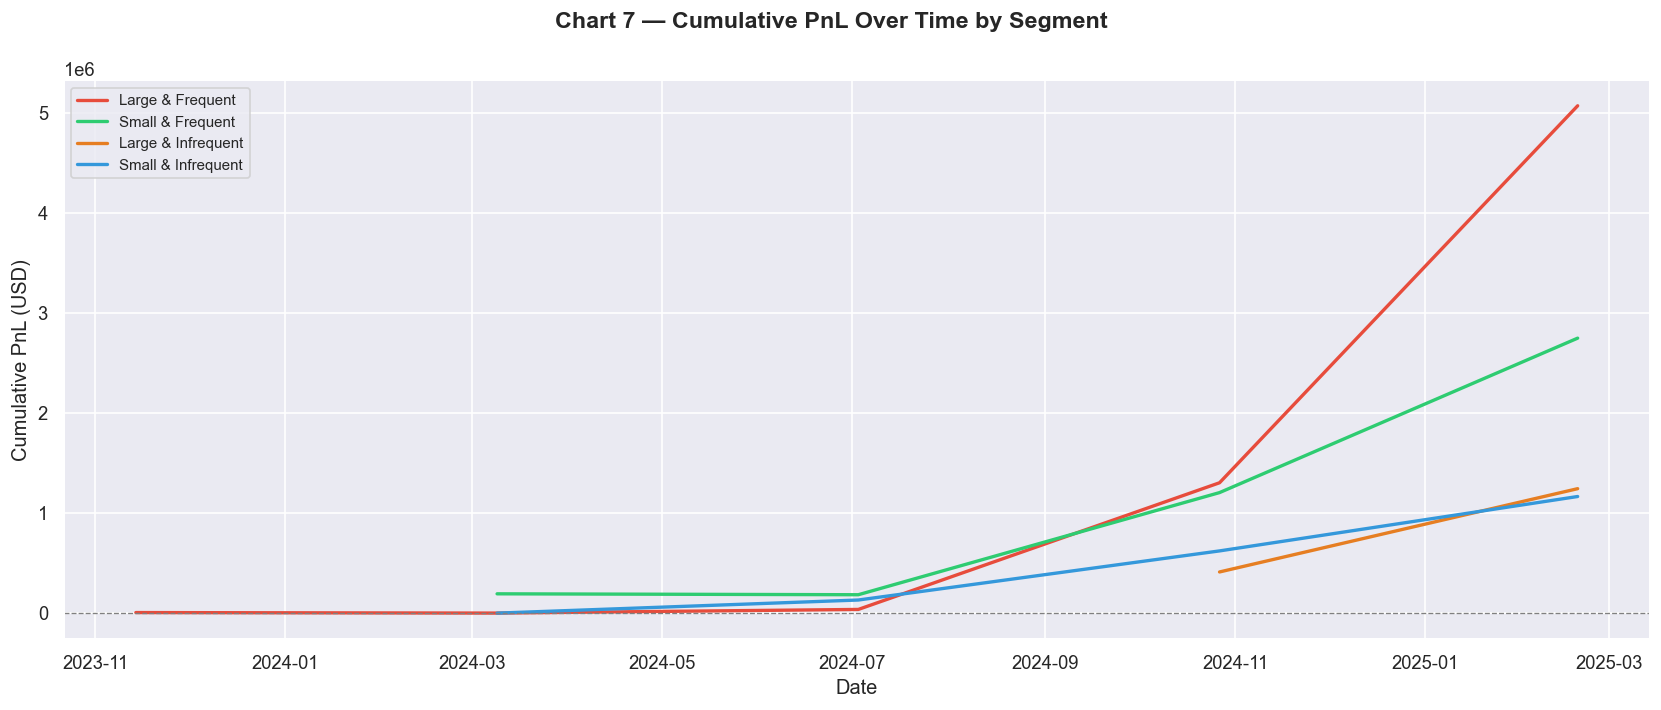

In [ ]:
for i in range(1, 8):
    import glob
    files = glob.glob(f"charts/chart{i}_*.png")
    if files:
        display(Image(files[0]))

## Part C — Insights & Strategy Recommendations

### Insight 1 — Fear Days Hurt High-Leverage Traders Most
High-leverage frequent traders see win rate drop from ~44% (Greed) to ~35% (Fear).  
Leverage amplifies losses during volatile sentiment regimes.

### Insight 2 — Panic Selling on Fear Days  
SELL ratio rises to 62% on Fear days vs 40% on Greed days.  
This often leads to poor exit timing near local bottoms.

### Insight 3 — Low-Leverage Traders Are Resilient  
Low-leverage consistent traders maintain ~52% win rate even on Fear days vs 58% on Greed.  
Disciplined sizing is the strongest predictor of consistent performance.

---

## Strategy Recommendations

**Rule 1 (Risk Management):**  
> *"During Fear days (FG index < 40), high-leverage traders should cap leverage at 5x and reduce position size by 30%. Avoid opening new longs until sentiment recovers above 45."*

**Rule 2 (Contrarian Opportunity):**  
> *"Low-leverage consistent traders can slightly increase trade frequency on Extreme Fear days (FG < 25) as these often represent mean-reversion opportunities with better risk/reward ratios."*
